In [1]:
import os
import json
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    roc_auc_score,
    average_precision_score,
    roc_curve,
)

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

warnings.filterwarnings("ignore")
print("Imports loaded.")

Imports loaded.


In [2]:
from pathlib import Path

# =========================
# MAIN CONFIG
# =========================
MODEL_NAME = "mobilenetv3_small"
MAIN_SEED = 42

USE_PRETRAINED = True
USE_WEIGHTED_LOSS = True
USE_LABEL_SMOOTHING = True

NUM_EPOCHS = 25
EARLY_STOPPING_PATIENCE = 6
BATCH_SIZE = 32
NUM_WORKERS = 0
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-4

THRESHOLD_COVERAGES = [0.95, 0.90, 0.80]

# Split ratios for the 9 known classes
TRAIN_RATIO = 0.70
VAL_RATIO = 0.15
TEST_RATIO = 0.15

assert abs(TRAIN_RATIO + VAL_RATIO + TEST_RATIO - 1.0) < 1e-8

# =========================
# PATHS
# =========================
CANDIDATE_BASE_DIRS = [
    Path("/mnt/e/CVPR"),
    Path("/mnt/d/CVPR"),
    Path(r"E:\CVPR"),
    Path(r"D:\CVPR"),
]

BASE_DIR = None
for p in CANDIDATE_BASE_DIRS:
    if p.exists():
        BASE_DIR = p
        break

if BASE_DIR is None:
    raise FileNotFoundError("Could not find CVPR folder.")

PROJECT_ROOT = BASE_DIR / "steel_failure_aware"
RAW_GC10_DIR = BASE_DIR / "GC10"

RUNS_DIR = PROJECT_ROOT / "runs"
CLOSED_SET_DIR = RUNS_DIR / "closed_set"
LOCO_DIR = RUNS_DIR / "internal_unknown_gc10_loco"
LOCO_DIR.mkdir(parents=True, exist_ok=True)

REFERENCE_RUN_NAME = "mobilenetv3_small__adamw__weightedCE_True__labelsmooth_True__pretrained_True__seed_42"
REFERENCE_CONFIG_JSON = CLOSED_SET_DIR / REFERENCE_RUN_NAME / "config.json"

if not REFERENCE_CONFIG_JSON.exists():
    raise FileNotFoundError(f"Reference config not found: {REFERENCE_CONFIG_JSON}")

with open(REFERENCE_CONFIG_JSON, "r", encoding="utf-8") as f:
    ref_cfg = json.load(f)

IMAGE_SIZE = int(ref_cfg["image_size"])
TRAIN_MEAN = ref_cfg["train_mean"]
TRAIN_STD = ref_cfg["train_std"]

print("PROJECT_ROOT:", PROJECT_ROOT)
print("RAW_GC10_DIR:", RAW_GC10_DIR)
print("LOCO_DIR    :", LOCO_DIR)
print("IMAGE_SIZE  :", IMAGE_SIZE)
print("TRAIN_MEAN  :", TRAIN_MEAN)
print("TRAIN_STD   :", TRAIN_STD)

PROJECT_ROOT: /mnt/e/CVPR/steel_failure_aware
RAW_GC10_DIR: /mnt/e/CVPR/GC10
LOCO_DIR    : /mnt/e/CVPR/steel_failure_aware/runs/internal_unknown_gc10_loco
IMAGE_SIZE  : 224
TRAIN_MEAN  : [0.3359968066215515, 0.3359968066215515, 0.3359968066215515]
TRAIN_STD   : [0.1534603238105774, 0.1534603238105774, 0.1534603238105774]


In [3]:
def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)

set_seed(MAIN_SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Using device: cuda
GPU: NVIDIA GeForce RTX 5060 Ti


In [4]:
IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".webp"}

class_dirs = []
for d in RAW_GC10_DIR.iterdir():
    if d.is_dir() and d.name.isdigit():
        class_dirs.append(d)

class_dirs = sorted(class_dirs, key=lambda x: int(x.name))
orig_classes = [int(d.name) for d in class_dirs]

gc10_records = []
for d in class_dirs:
    orig_label = int(d.name)
    for p in d.rglob("*"):
        if p.is_file() and p.suffix.lower() in IMAGE_EXTS:
            gc10_records.append({
                "filepath": str(p),
                "orig_label": orig_label,
            })

gc10_df = pd.DataFrame(gc10_records)
print("Total images:", len(gc10_df))
print("Classes:", sorted(gc10_df["orig_label"].unique().tolist()))
display(gc10_df.head())

Total images: 2312
Classes: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]


,filepath,orig_label
0,/mnt/e/CVPR/GC10/1/img_02_425501900_00017.jpg,1
1,/mnt/e/CVPR/GC10/1/img_02_425502300_00018.jpg,1
2,/mnt/e/CVPR/GC10/1/img_02_425503100_00017.jpg,1
3,/mnt/e/CVPR/GC10/1/img_02_425505500_00018.jpg,1
4,/mnt/e/CVPR/GC10/1/img_02_425506300_00018.jpg,1


In [5]:
train_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ToTensor(),
    transforms.Normalize(mean=TRAIN_MEAN, std=TRAIN_STD),
])

eval_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=TRAIN_MEAN, std=TRAIN_STD),
])

class ImageClassificationDataset(Dataset):
    def __init__(self, df, transform, label_col="label"):
        self.df = df.reset_index(drop=True)
        self.transform = transform
        self.label_col = label_col

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row["filepath"]).convert("L")
        img = self.transform(img)
        label = int(row[self.label_col])
        return img, label, row["filepath"]

print("Dataset class ready.")

Dataset class ready.


In [6]:
def build_mobilenetv3_small(num_classes=9, use_pretrained=True):
    try:
        weights = models.MobileNet_V3_Small_Weights.IMAGENET1K_V1 if use_pretrained else None
        model = models.mobilenet_v3_small(weights=weights)
    except Exception:
        model = models.mobilenet_v3_small(pretrained=use_pretrained)

    in_features = model.classifier[-1].in_features
    model.classifier[-1] = nn.Linear(in_features, num_classes)
    return model

def macro_f1_np(y_true, y_pred):
    _, _, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="macro", zero_division=0
    )
    return float(f1)

def softmax_numpy(logits):
    logits = logits - np.max(logits, axis=1, keepdims=True)
    exps = np.exp(logits)
    return exps / np.sum(exps, axis=1, keepdims=True)

def fpr_at_95_tpr(y_true_unknown, anomaly_scores):
    fpr, tpr, _ = roc_curve(y_true_unknown, anomaly_scores)
    idx = np.where(tpr >= 0.95)[0]
    if len(idx) == 0:
        return 1.0
    return float(fpr[idx[0]])

def fit_temperature(val_logits_np, val_labels_np, device):
    logits = torch.tensor(val_logits_np, dtype=torch.float32, device=device)
    labels = torch.tensor(val_labels_np, dtype=torch.long, device=device)

    temperature = nn.Parameter(torch.ones(1, device=device))
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.LBFGS([temperature], lr=0.01, max_iter=100)

    def closure():
        optimizer.zero_grad()
        loss = criterion(logits / temperature.clamp(min=1e-6), labels)
        loss.backward()
        return loss

    optimizer.step(closure)
    return float(temperature.detach().cpu().item())

def predict_logits(model, loader, device):
    model.eval()
    all_logits, all_labels, all_paths = [], [], []

    with torch.no_grad():
        for images, labels, paths in loader:
            images = images.to(device)
            outputs = model(images)
            all_logits.append(outputs.cpu().numpy())
            all_labels.append(labels.numpy())
            all_paths.extend(list(paths))

    all_logits = np.concatenate(all_logits, axis=0)
    all_labels = np.concatenate(all_labels, axis=0)
    return all_logits, all_labels, all_paths

In [7]:
def train_one_fold(model, train_loader, val_loader, criterion, optimizer, device, num_epochs=25, patience=6):
    best_state = None
    best_val_f1 = -1.0
    best_epoch = -1
    wait = 0
    history = []

    for epoch in range(1, num_epochs + 1):
        model.train()

        train_losses = []
        train_true, train_pred = [], []

        for images, labels, _ in train_loader:
            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_losses.append(loss.item())
            preds = torch.argmax(outputs, dim=1)
            train_true.extend(labels.cpu().numpy().tolist())
            train_pred.extend(preds.cpu().numpy().tolist())

        train_loss = float(np.mean(train_losses))
        train_f1 = macro_f1_np(np.array(train_true), np.array(train_pred))

        model.eval()
        val_losses = []
        val_true, val_pred = [], []

        with torch.no_grad():
            for images, labels, _ in val_loader:
                images = images.to(device)
                labels = labels.to(device)

                outputs = model(images)
                loss = criterion(outputs, labels)

                val_losses.append(loss.item())
                preds = torch.argmax(outputs, dim=1)
                val_true.extend(labels.cpu().numpy().tolist())
                val_pred.extend(preds.cpu().numpy().tolist())

        val_loss = float(np.mean(val_losses))
        val_f1 = macro_f1_np(np.array(val_true), np.array(val_pred))

        history.append({
            "epoch": epoch,
            "train_loss": train_loss,
            "val_loss": val_loss,
            "train_macro_f1": train_f1,
            "val_macro_f1": val_f1,
        })

        print(f"Epoch {epoch:02d}/{num_epochs} | "
              f"train_loss={train_loss:.4f} | val_loss={val_loss:.4f} | "
              f"train_macro_f1={train_f1:.4f} | val_macro_f1={val_f1:.4f}")

        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            best_epoch = epoch
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            wait = 0
        else:
            wait += 1

        if wait >= patience:
            print(f"Early stopping at epoch {epoch}.")
            break

    model.load_state_dict(best_state)
    history_df = pd.DataFrame(history)
    return model, history_df, best_epoch, best_val_f1

In [8]:
def run_loco_fold(left_out_class, seed=42):
    print("=" * 80)
    print(f"LEFT-OUT CLASS = {left_out_class}")
    print("=" * 80)

    fold_dir = LOCO_DIR / f"leftout_{left_out_class}"
    fold_dir.mkdir(parents=True, exist_ok=True)

    known_df = gc10_df[gc10_df["orig_label"] != left_out_class].copy()
    unknown_df = gc10_df[gc10_df["orig_label"] == left_out_class].copy()

    known_classes = sorted(known_df["orig_label"].unique().tolist())
    label_map = {orig_cls: idx for idx, orig_cls in enumerate(known_classes)}
    known_df["label"] = known_df["orig_label"].map(label_map)

    # known split: train / val / test
    train_df, temp_df = train_test_split(
        known_df,
        test_size=(1.0 - TRAIN_RATIO),
        stratify=known_df["label"],
        random_state=seed
    )

    val_relative = VAL_RATIO / (VAL_RATIO + TEST_RATIO)
    val_df, test_df = train_test_split(
        temp_df,
        test_size=(1.0 - val_relative),
        stratify=temp_df["label"],
        random_state=seed
    )

    print("Known train:", len(train_df))
    print("Known val  :", len(val_df))
    print("Known test :", len(test_df))
    print("Unknown    :", len(unknown_df))

    train_ds = ImageClassificationDataset(train_df, train_transform, label_col="label")
    val_ds = ImageClassificationDataset(val_df, eval_transform, label_col="label")
    test_ds = ImageClassificationDataset(test_df, eval_transform, label_col="label")

    # unknown labels are dummy -1
    unknown_eval_df = unknown_df.copy()
    unknown_eval_df["label"] = -1
    unknown_ds = ImageClassificationDataset(unknown_eval_df, eval_transform, label_col="label")

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
    val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
    test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
    unknown_loader = DataLoader(unknown_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

    model = build_mobilenetv3_small(num_classes=len(known_classes), use_pretrained=USE_PRETRAINED).to(DEVICE)

    if USE_WEIGHTED_LOSS:
        class_counts = train_df["label"].value_counts().sort_index().values.astype(np.float32)
        class_weights = class_counts.sum() / (len(class_counts) * class_counts)
        class_weights = torch.tensor(class_weights, dtype=torch.float32, device=DEVICE)
    else:
        class_weights = None

    criterion = nn.CrossEntropyLoss(
        weight=class_weights,
        label_smoothing=0.1 if USE_LABEL_SMOOTHING else 0.0
    )

    optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

    model, history_df, best_epoch, best_val_f1 = train_one_fold(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        criterion=criterion,
        optimizer=optimizer,
        device=DEVICE,
        num_epochs=NUM_EPOCHS,
        patience=EARLY_STOPPING_PATIENCE,
    )

    # save model/history
    torch.save(model.state_dict(), fold_dir / "best_model.pth")
    history_df.to_csv(fold_dir / "train_history.csv", index=False)

    # inference
    val_logits, val_labels, val_paths = predict_logits(model, val_loader, DEVICE)
    test_logits, test_labels, test_paths = predict_logits(model, test_loader, DEVICE)
    unk_logits, _, unk_paths = predict_logits(model, unknown_loader, DEVICE)

    val_probs_raw = softmax_numpy(val_logits)
    test_probs_raw = softmax_numpy(test_logits)
    unk_probs_raw = softmax_numpy(unk_logits)

    temperature = fit_temperature(val_logits, val_labels, DEVICE)

    val_logits_cal = val_logits / temperature
    test_logits_cal = test_logits / temperature
    unk_logits_cal = unk_logits / temperature

    val_probs_cal = softmax_numpy(val_logits_cal)
    test_probs_cal = softmax_numpy(test_logits_cal)
    unk_probs_cal = softmax_numpy(unk_logits_cal)

    # predictions for known test
    test_pred_raw = np.argmax(test_probs_raw, axis=1)

    # scores
    known_val_raw = np.max(val_probs_raw, axis=1)
    known_test_raw = np.max(test_probs_raw, axis=1)
    unknown_raw = np.max(unk_probs_raw, axis=1)

    known_val_cal = np.max(val_probs_cal, axis=1)
    known_test_cal = np.max(test_probs_cal, axis=1)
    unknown_cal = np.max(unk_probs_cal, axis=1)

    score_dict = {
        "raw_msp": (known_val_raw, known_test_raw, unknown_raw),
        "calibrated_msp": (known_val_cal, known_test_cal, unknown_cal),
    }

    metric_rows = []
    threshold_rows = []

    for score_name, (known_val_conf, known_test_conf, unknown_conf) in score_dict.items():
        y_binary = np.concatenate([
            np.zeros(len(known_test_conf), dtype=np.int64),
            np.ones(len(unknown_conf), dtype=np.int64),
        ])

        anomaly_scores = np.concatenate([
            -known_test_conf,
            -unknown_conf,
        ])

        auroc = roc_auc_score(y_binary, anomaly_scores)
        aupr = average_precision_score(y_binary, anomaly_scores)
        fpr95 = fpr_at_95_tpr(y_binary, anomaly_scores)

        metric_rows.append({
            "left_out_class": left_out_class,
            "model": MODEL_NAME,
            "seed": seed,
            "score_name": score_name,
            "temperature": temperature,
            "auroc_unknown_positive": float(auroc),
            "aupr_unknown_positive": float(aupr),
            "fpr_at_95_tpr": float(fpr95),
            "n_known_test": int(len(known_test_conf)),
            "n_unknown": int(len(unknown_conf)),
            "best_epoch": int(best_epoch),
            "best_val_macro_f1": float(best_val_f1),
        })

        for cov in THRESHOLD_COVERAGES:
            threshold = float(np.quantile(known_val_conf, 1.0 - cov))
            known_accept = known_test_conf >= threshold
            unknown_accept = unknown_conf >= threshold

            known_accept_rate = float(np.mean(known_accept))
            unknown_reject_rate = 1.0 - float(np.mean(unknown_accept))

            if known_accept.sum() > 0:
                known_acc_after_reject = float(
                    accuracy_score(test_labels[known_accept], test_pred_raw[known_accept])
                )
            else:
                known_acc_after_reject = np.nan

            threshold_rows.append({
                "left_out_class": left_out_class,
                "model": MODEL_NAME,
                "seed": seed,
                "score_name": score_name,
                "target_val_coverage": float(cov),
                "threshold": threshold,
                "known_accept_rate_test": known_accept_rate,
                "known_accuracy_after_reject": known_acc_after_reject,
                "unknown_reject_rate_unknown": unknown_reject_rate,
            })

        # histogram
        plt.figure(figsize=(8, 6))
        plt.hist(known_test_conf, bins=30, alpha=0.6, label="Known test", density=True)
        plt.hist(unknown_conf, bins=30, alpha=0.6, label=f"Unknown class {left_out_class}", density=True)
        plt.xlabel("Confidence score")
        plt.ylabel("Density")
        plt.title(f"LOCO Known vs Unknown - left_out_{left_out_class} - {score_name}")
        plt.legend()
        plt.tight_layout()
        plt.savefig(fold_dir / f"histogram_{score_name}.png", dpi=200)
        plt.close()

    metrics_df = pd.DataFrame(metric_rows)
    thresholds_df = pd.DataFrame(threshold_rows)

    metrics_df.to_csv(fold_dir / "loco_metrics.csv", index=False)
    thresholds_df.to_csv(fold_dir / "loco_thresholds.csv", index=False)

    with open(fold_dir / "temperature.json", "w", encoding="utf-8") as f:
        json.dump({"temperature": temperature}, f, indent=2)

    return metrics_df, thresholds_df

In [9]:
all_metrics = []
all_thresholds = []

for left_out_class in sorted(orig_classes):
    metrics_df, thresholds_df = run_loco_fold(left_out_class=left_out_class, seed=MAIN_SEED)
    all_metrics.append(metrics_df)
    all_thresholds.append(thresholds_df)

all_metrics_df = pd.concat(all_metrics, ignore_index=True)
all_thresholds_df = pd.concat(all_thresholds, ignore_index=True)

all_metrics_csv = LOCO_DIR / "all_loco_metrics.csv"
all_thresholds_csv = LOCO_DIR / "all_loco_thresholds.csv"

all_metrics_df.to_csv(all_metrics_csv, index=False)
all_thresholds_df.to_csv(all_thresholds_csv, index=False)

print("Saved:", all_metrics_csv)
print("Saved:", all_thresholds_csv)
display(all_metrics_df.head())
display(all_thresholds_df.head())

LEFT-OUT CLASS = 1
Known train: 1465
Known val  : 314
Known test : 314
Unknown    : 219
Epoch 01/25 | train_loss=2.3412 | val_loss=2.4338 | train_macro_f1=0.1631 | val_macro_f1=0.0930
Epoch 02/25 | train_loss=2.0117 | val_loss=2.2741 | train_macro_f1=0.3607 | val_macro_f1=0.2290
Epoch 03/25 | train_loss=1.7525 | val_loss=2.0034 | train_macro_f1=0.5004 | val_macro_f1=0.4000
Epoch 04/25 | train_loss=1.5634 | val_loss=1.7846 | train_macro_f1=0.6217 | val_macro_f1=0.4740
Epoch 05/25 | train_loss=1.4277 | val_loss=1.6779 | train_macro_f1=0.6730 | val_macro_f1=0.5267
Epoch 06/25 | train_loss=1.3649 | val_loss=1.6287 | train_macro_f1=0.7114 | val_macro_f1=0.5347
Epoch 07/25 | train_loss=1.2854 | val_loss=1.5925 | train_macro_f1=0.7477 | val_macro_f1=0.5860
Epoch 08/25 | train_loss=1.2313 | val_loss=1.5227 | train_macro_f1=0.7740 | val_macro_f1=0.6304
Epoch 09/25 | train_loss=1.2165 | val_loss=1.4726 | train_macro_f1=0.7746 | val_macro_f1=0.6223
Epoch 10/25 | train_loss=1.1678 | val_loss=1.420

,left_out_class,model,seed,score_name,temperature,auroc_unknown_positive,aupr_unknown_positive,fpr_at_95_tpr,n_known_test,n_unknown,best_epoch,best_val_macro_f1
0,1,mobilenetv3_small,42,raw_msp,0.615550,0.538566,0.512070,0.939490,314,219,25,0.799246
1,1,mobilenetv3_small,42,calibrated_msp,0.615550,0.534203,0.502616,0.942675,314,219,25,0.799246
2,2,mobilenetv3_small,42,raw_msp,0.617090,0.586631,0.551084,0.918301,306,273,14,0.820880
3,2,mobilenetv3_small,42,calibrated_msp,0.617090,0.595663,0.558889,0.911765,306,273,14,0.820880
4,3,mobilenetv3_small,42,raw_msp,0.634949,0.662777,0.609141,0.891374,313,226,24,0.796657


,left_out_class,model,seed,score_name,target_val_coverage,threshold,known_accept_rate_test,known_accuracy_after_reject,unknown_reject_rate_unknown
0,1,mobilenetv3_small,42,raw_msp,0.95,0.326208,0.958599,0.900332,0.127854
1,1,mobilenetv3_small,42,raw_msp,0.90,0.410106,0.894904,0.921708,0.251142
2,1,mobilenetv3_small,42,raw_msp,0.80,0.492593,0.834395,0.931298,0.337900
3,1,mobilenetv3_small,42,calibrated_msp,0.95,0.472009,0.939490,0.908475,0.146119
4,1,mobilenetv3_small,42,calibrated_msp,0.90,0.561700,0.904459,0.922535,0.219178


In [10]:
summary_rows = []

for score_name in ["raw_msp", "calibrated_msp"]:
    sub = all_metrics_df[all_metrics_df["score_name"] == score_name].copy()

    summary_rows.append({
        "model": MODEL_NAME,
        "seed": MAIN_SEED,
        "score_name": score_name,
        "mean_auroc": float(sub["auroc_unknown_positive"].mean()),
        "std_auroc": float(sub["auroc_unknown_positive"].std(ddof=1)),
        "mean_aupr": float(sub["aupr_unknown_positive"].mean()),
        "std_aupr": float(sub["aupr_unknown_positive"].std(ddof=1)),
        "mean_fpr95": float(sub["fpr_at_95_tpr"].mean()),
        "std_fpr95": float(sub["fpr_at_95_tpr"].std(ddof=1)),
    })

summary_df = pd.DataFrame(summary_rows)
summary_csv = LOCO_DIR / "loco_summary_across_folds.csv"
summary_df.to_csv(summary_csv, index=False)

print("Saved:", summary_csv)
display(summary_df)

Saved: /mnt/e/CVPR/steel_failure_aware/runs/internal_unknown_gc10_loco/loco_summary_across_folds.csv


,model,seed,score_name,mean_auroc,std_auroc,mean_aupr,std_aupr,mean_fpr95,std_fpr95
0,mobilenetv3_small,42,raw_msp,0.683701,0.100603,0.561186,0.186034,0.848189,0.127947
1,mobilenetv3_small,42,calibrated_msp,0.684971,0.095882,0.560400,0.180769,0.843348,0.133899


In [11]:
threshold_summary_rows = []

for score_name in ["raw_msp", "calibrated_msp"]:
    for cov in THRESHOLD_COVERAGES:
        sub = all_thresholds_df[
            (all_thresholds_df["score_name"] == score_name) &
            (all_thresholds_df["target_val_coverage"].round(2) == round(cov, 2))
        ].copy()

        threshold_summary_rows.append({
            "model": MODEL_NAME,
            "seed": MAIN_SEED,
            "score_name": score_name,
            "target_val_coverage": cov,
            "mean_known_accept_rate_test": float(sub["known_accept_rate_test"].mean()),
            "mean_known_accuracy_after_reject": float(sub["known_accuracy_after_reject"].mean()),
            "mean_unknown_reject_rate": float(sub["unknown_reject_rate_unknown"].mean()),
        })

threshold_summary_df = pd.DataFrame(threshold_summary_rows)
threshold_summary_csv = LOCO_DIR / "loco_threshold_summary_across_folds.csv"
threshold_summary_df.to_csv(threshold_summary_csv, index=False)

print("Saved:", threshold_summary_csv)
display(threshold_summary_df)

Saved: /mnt/e/CVPR/steel_failure_aware/runs/internal_unknown_gc10_loco/loco_threshold_summary_across_folds.csv


,model,seed,score_name,target_val_coverage,mean_known_accept_rate_test,mean_known_accuracy_after_reject,mean_unknown_reject_rate
0,mobilenetv3_small,42,raw_msp,0.95,0.951959,0.866132,0.189476
1,mobilenetv3_small,42,raw_msp,0.90,0.908379,0.879066,0.308626
2,mobilenetv3_small,42,raw_msp,0.80,0.815096,0.900033,0.470720
3,mobilenetv3_small,42,calibrated_msp,0.95,0.950141,0.867700,0.183460
4,mobilenetv3_small,42,calibrated_msp,0.90,0.910875,0.880985,0.291052
5,mobilenetv3_small,42,calibrated_msp,0.80,0.811054,0.908167,0.468215


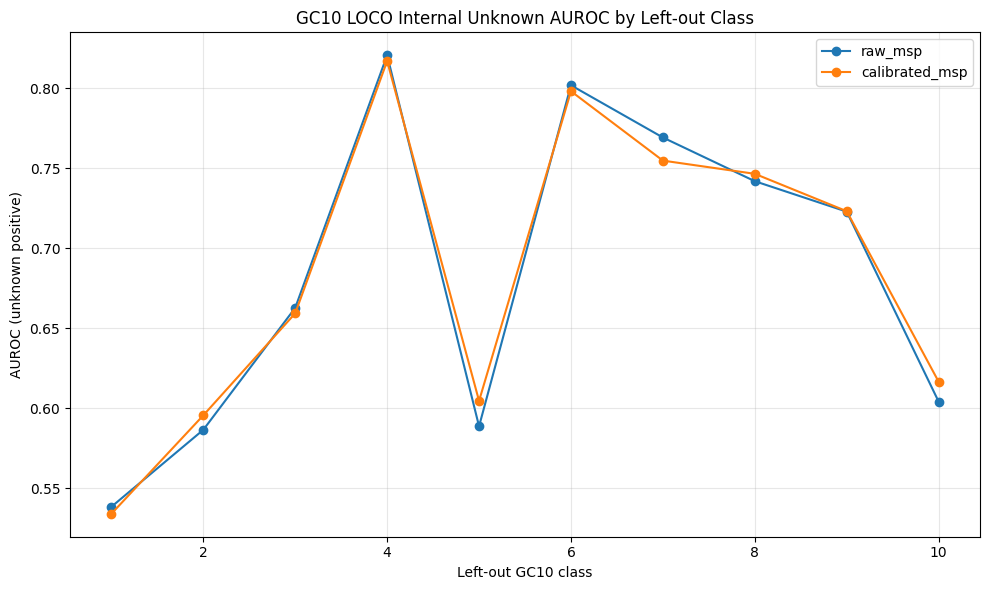

In [12]:
plt.figure(figsize=(10, 6))

for score_name in ["raw_msp", "calibrated_msp"]:
    sub = all_metrics_df[all_metrics_df["score_name"] == score_name].sort_values("left_out_class")
    plt.plot(sub["left_out_class"], sub["auroc_unknown_positive"], marker="o", label=score_name)

plt.xlabel("Left-out GC10 class")
plt.ylabel("AUROC (unknown positive)")
plt.title("GC10 LOCO Internal Unknown AUROC by Left-out Class")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(LOCO_DIR / "loco_auroc_by_fold.png", dpi=200)
plt.show()

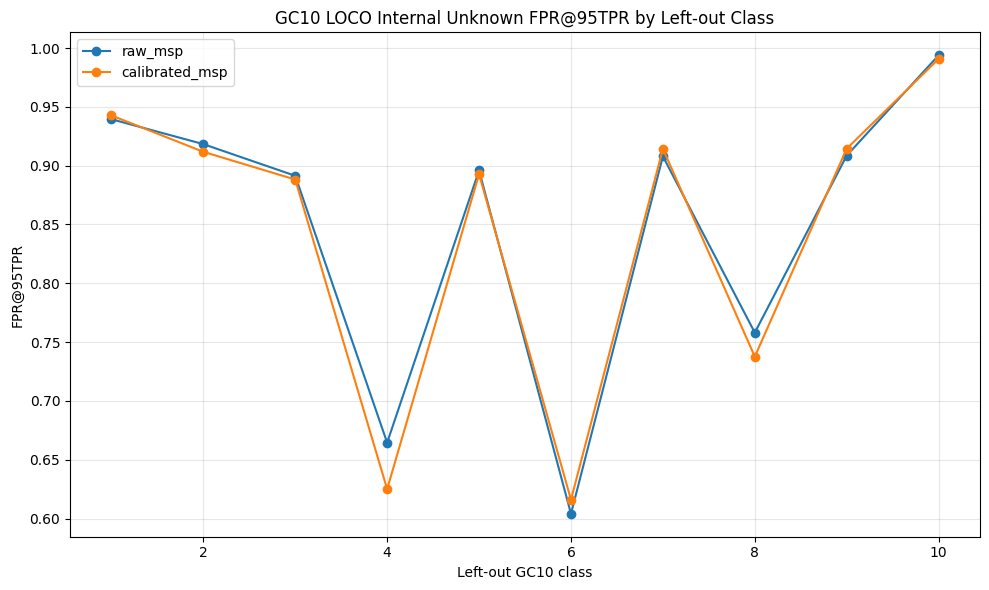

In [13]:
plt.figure(figsize=(10, 6))

for score_name in ["raw_msp", "calibrated_msp"]:
    sub = all_metrics_df[all_metrics_df["score_name"] == score_name].sort_values("left_out_class")
    plt.plot(sub["left_out_class"], sub["fpr_at_95_tpr"], marker="o", label=score_name)

plt.xlabel("Left-out GC10 class")
plt.ylabel("FPR@95TPR")
plt.title("GC10 LOCO Internal Unknown FPR@95TPR by Left-out Class")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(LOCO_DIR / "loco_fpr95_by_fold.png", dpi=200)
plt.show()